# Mini-Project 4: Rainfall Pattern & Crop Suitability Analyser

**Scenario.** An agricultural extension officer wants to compare rainfall regimes across regions and advise farmers on
which months suit which crops. Data: illustrative mean monthly rainfall (mm, Jan–Dec) for Kampala, Gulu and Mbarara.

Code: `src/rainfall/`: `region.py` (`Region`), `crops.py` (`CropRule`, `Suitability`), `similarity.py` (cosine,
Pearson, Euclidean), `seasons.py` (`find_peaks` season detection), `advisory.py`, `plotting.py`.

In [1]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance

from src.core.plotting import apply_style
from src.rainfall import (
    DEFAULT_CROP_RULES, MONTHS, Region, all_matrices, cosine_similarity, detect_seasons, euclidean_distance,
    good_runs, pearson_correlation, scipy_cosine_similarity,
)
from src.rainfall.data import EXPECTED_MODALITY, load_regions
from src.rainfall.plotting import plot_rainfall, plot_suitability_heatmap

apply_style()
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
regions = load_regions()

## 1. The `Region` class

In [2]:
pd.DataFrame([{ "region": r.name, "annual total (mm)": r.annual_total(), "monthly mean (mm)": r.mean(),
                "wettest": r.wettest_month(), "driest": r.driest_month(),
                "CV (seasonality)": r.coefficient_of_variation()} for r in regions]).set_index("region")

,annual total (mm),monthly mean (mm),wettest,driest,CV (seasonality)
region,,,,,
Kampala,"1,600.000",133.333,May,Sep,0.388
Gulu,"1,388.000",115.667,Aug,Jan,0.642
Mbarara,"1,040.000",86.667,Apr,Jul,0.444


Kampala is the wettest (1,600 mm) and least seasonal (CV ≈ 0.39). Gulu is not far behind in total (1,388 mm), but its
rain comes in one long wet season with a very dry December–February, so its CV (0.64) is about 1.7× Kampala's. Mbarara is the driest
region, with a pronounced June–July dry spell.

## 2. `CropRule`: month-by-month suitability

Each rule is a monthly rainfall band during the growing season. The thresholds come from seasonal crop water
requirements (Brouwer & Heibloem, 1986; DaMatta & Ramalho, 2006) divided by the length of the growing period:

In [3]:
pd.DataFrame([{ "crop": c.crop, "min mm/month": c.min_mm, "max mm/month": c.max_mm,
                "derivation": c.rationale, "source": c.source} for c in DEFAULT_CROP_RULES]).set_index("crop")

,min mm/month,max mm/month,derivation,source
crop,,,,
Maize,125.000,200.000,500-800 mm per growing period of ~4 months (12...,"Brouwer, C. & Heibloem, M. (1986). Irrigation ..."
Beans,100.000,170.000,300-500 mm per growing period of ~3 months (95...,"Brouwer, C. & Heibloem, M. (1986). Irrigation ..."
Coffee,100.000,200.000,"optimum annual rainfall ~1,200-1,800 mm, i.e. ...","DaMatta, F. M. & Ramalho, J. D. C. (2006). Imp..."


In [4]:
classified = pd.DataFrame(
    {(rule.crop, r.name): [s.label(rule.crop) for s in rule.classify(r.rainfall)]
     for rule in DEFAULT_CROP_RULES for r in regions}, index=MONTHS).T
classified

Jan              Feb                Mar  \
Maize  Kampala     Drought risk   Good for maize     Good for maize   
       Gulu        Drought risk     Drought risk       Drought risk   
       Mbarara     Drought risk     Drought risk       Drought risk   
Beans  Kampala   Good for beans   Good for beans  Waterlogging risk   
       Gulu        Drought risk     Drought risk       Drought risk   
       Mbarara     Drought risk     Drought risk     Good for beans   
Coffee Kampala  Good for coffee  Good for coffee    Good for coffee   
       Gulu        Drought risk     Drought risk       Drought risk   
       Mbarara     Drought risk     Drought risk    Good for coffee   

                              Apr                May                Jun  \
Maize  Kampala     Good for maize  Waterlogging risk     Good for maize   
       Gulu        Good for maize     Good for maize     Good for maize   
       Mbarara     Good for maize       Drought risk       Drought risk   
Beans  Kampala  Waterlogging risk  Waterlogging risk  Waterlogging risk   
       Gulu        Good for beans  Waterlogging risk     Good for beans   
       Mbarara     Good for beans       Drought risk       Drought risk   
Coffee Kampala    Good for coffee  Waterlogging risk    Good for coffee   
       Gulu       Good for coffee    Good for coffee    Good for coffee   
       Mbarara    Good for coffee       Drought risk       Drought risk   

                            Jul                Aug                Sep  \
Maize  Kampala     Drought risk       Drought risk       Drought risk   
       Gulu      Good for maize  Waterlogging risk     Good for maize   
       Mbarara     Drought risk       Drought risk       Drought risk   
Beans  Kampala     Drought risk       Drought risk       Drought risk   
       Gulu      Good for beans  Waterlogging risk  Waterlogging risk   
       Mbarara     Drought risk       Drought risk     Good for beans   
Coffee Kampala     Drought risk       Drought risk       Drought risk   
       Gulu     Good for coffee  Waterlogging risk    Good for coffee   
       Mbarara     Drought risk       Drought risk    Good for coffee   

                            Oct              Nov              Dec  
Maize  Kampala     Drought risk     Drought risk   Good for maize  
       Gulu      Good for maize     Drought risk     Drought risk  
       Mbarara   Good for maize     Drought risk     Drought risk  
Beans  Kampala   Good for beans   Good for beans   Good for beans  
       Gulu      Good for beans     Drought risk     Drought risk  
       Mbarara   Good for beans   Good for beans     Drought risk  
Coffee Kampala  Good for coffee  Good for coffee  Good for coffee  
       Gulu     Good for coffee     Drought risk     Drought risk  
       Mbarara  Good for coffee  Good for coffee     Drought risk

In [5]:
# Count of suitable months per crop and region.
pd.DataFrame({rule.crop: {r.name: int((rule.codes(r) == 0).sum()) for r in regions} for rule in DEFAULT_CROP_RULES})

,Maize,Beans,Coffee
Kampala,5,5,8
Gulu,6,4,6
Mbarara,2,5,5


## 3. Correcting last year's cosine similarity

Last year's question used `math.cos()`. That function returns the cosine of an **angle in radians**. Applied to
rainfall it yields numbers with no meaning. Cosine **similarity** is the cosine of the angle *between two vectors* (Manning, Raghavan & Schütze, 2008,
§6.3):

$$\cos\theta = \frac{\mathbf a\cdot\mathbf b}{\lVert\mathbf a\rVert\,\lVert\mathbf b\rVert}.$$

In [6]:
kla, gulu, mbr = regions
print("math.cos(annual total of Kampala) =", round(math.cos(kla.annual_total()), 4), "  <- cosine of 1610 radians: meaningless")
print("math.cos(Kampala·Gulu dot product) =", round(math.cos(float(np.dot(kla.rainfall, gulu.rainfall))), 4), "  <- also meaningless")
print()
diffs = []
for a in regions:
    for b in regions:
        ours, ref = cosine_similarity(a.rainfall, b.rainfall), 1 - distance.cosine(a.rainfall, b.rainfall)
        diffs.append(abs(ours - ref))
        if a.name < b.name:
            print(f"{a.name:>8} vs {b.name:<8}: NumPy {ours:.6f} | 1 - scipy.spatial.distance.cosine {ref:.6f}")
print(f"\nmax |difference| over all pairs = {max(diffs):.2e}  -> implementation verified")

math.cos(annual total of Kampala) = -0.5984   <- cosine of 1610 radians: meaningless
math.cos(Kampala·Gulu dot product) = -0.8765   <- also meaningless

 Kampala vs Mbarara : NumPy 0.891250 | 1 - scipy.spatial.distance.cosine 0.891250
    Gulu vs Kampala : NumPy 0.786609 | 1 - scipy.spatial.distance.cosine 0.786609
    Gulu vs Mbarara : NumPy 0.748678 | 1 - scipy.spatial.distance.cosine 0.748678

max |difference| over all pairs = 2.22e-16  -> implementation verified


## 4. Similarity and distance matrices

In [7]:
matrices = all_matrices(regions)
for name, m in matrices.items():
    print(name)
    display(pd.DataFrame(m.values, index=m.labels, columns=m.labels).round(3))

Cosine similarity


,Kampala,Gulu,Mbarara
Kampala,1.000,0.787,0.891
Gulu,0.787,1.000,0.749
Mbarara,0.891,0.749,1.000


Pearson correlation


,Kampala,Gulu,Mbarara
Kampala,1.000,-0.066,0.209
Gulu,-0.066,1.000,-0.174
Mbarara,0.209,-0.174,1.000


Euclidean distance (mm)


,Kampala,Gulu,Mbarara
Kampala,0.000,315.268,250.400
Gulu,315.268,0.000,312.800
Mbarara,250.400,312.800,0.000


In [8]:
# Pearson correlation cross-check against NumPy's corrcoef.
print("np.corrcoef matches:", np.allclose(np.corrcoef([r.rainfall for r in regions]), matrices["Pearson correlation"].values))

# Why cosine similarity ignores scale: a synthetic "Dry Kampala" with exactly half the rain.
dry_kla = Region("Dry Kampala (50 %)", kla.rainfall * 0.5)
print(f"Kampala vs Dry Kampala: cosine = {cosine_similarity(kla.rainfall, dry_kla.rainfall):.3f}, "
      f"Pearson = {pearson_correlation(kla.rainfall, dry_kla.rainfall):.3f}, "
      f"Euclidean = {euclidean_distance(kla.rainfall, dry_kla.rainfall):.0f} mm, annual deficit = {kla.annual_total()-dry_kla.annual_total():.0f} mm")

np.corrcoef matches: True
Kampala vs Dry Kampala: cosine = 1.000, Pearson = 1.000, Euclidean = 246 mm, annual deficit = 800 mm


**Why cosine similarity can call a much wetter region "similar".** Cosine similarity measures only the *angle*
between two vectors, not their lengths. Multiplying one region's rainfall by any positive constant leaves the cosine
unchanged. A "Dry Kampala" with half the rain scores a perfect 1.000 even though it receives 800 mm less per year,
which matters enormously to a farmer. And because all rainfall values are non-negative, every pair of real regimes lies
in the same orthant, so cosine similarity is inflated towards 1 by the shared positive *level*. Kampala and Gulu score
0.79 although their seasonal patterns are essentially **uncorrelated** (Pearson −0.07).

The three measures answer different questions:
* **Cosine similarity.** Do the two regions have the same *mix* of rain across months, ignoring the amount?
* **Pearson correlation.** This is cosine similarity of the *mean-centred* vectors. Do wet and dry months line up?
  Kampala–Mbarara (0.21) share the March–May and Oct–Nov seasons, while Gulu anti-correlates with both.
* **Euclidean distance.** How many mm apart are the regions month by month? This combines shape and amount.

For agronomy, Pearson (timing) plus annual totals (amount) is more informative than cosine alone.

## 5. Detecting rainy seasons with `scipy.signal.find_peaks`

`detect_seasons` treats the year as **circular**: it tiles the 12 months three times and keeps the peaks in the middle
copy. Without that, `find_peaks` can never report January or December, because edge samples have only one neighbour.
A peak counts as a season only if its topographic **prominence** (as computed by SciPy; Virtanen et al.,
2020) is at least a fraction of the annual range. Otherwise a brief dip
inside one long season would be counted as two seasons. The table shows how the classification depends on that
threshold.

In [9]:
rows = []
for thr in (0.0, 0.10, 0.25):
    for r in regions:
        p = detect_seasons(r, min_relative_prominence=thr)
        rows.append({"threshold": thr, "region": r.name, "peaks": ", ".join(p.peak_names),
                     "relative prominence": ", ".join(f"{x:.2f}" for x in p.relative_prominences),
                     "detected": p.modality.value, "expected (literature)": EXPECTED_MODALITY[r.name],
                     "match": p.modality.value == EXPECTED_MODALITY[r.name]})
pd.DataFrame(rows).set_index(["threshold", "region"])

peaks relative prominence  detected  \
threshold region                                            
0.000     Kampala  May, Dec          1.00, 0.06   Bimodal   
          Gulu     May, Aug          0.22, 1.00   Bimodal   
          Mbarara  Apr, Oct          1.00, 0.46   Bimodal   
0.100     Kampala       May                1.00  Unimodal   
          Gulu     May, Aug          0.22, 1.00   Bimodal   
          Mbarara  Apr, Oct          1.00, 0.46   Bimodal   
0.250     Kampala       May                1.00  Unimodal   
          Gulu          Aug                1.00  Unimodal   
          Mbarara  Apr, Oct          1.00, 0.46   Bimodal   

                  expected (literature)  match  
threshold region                                
0.000     Kampala               Bimodal   True  
          Gulu                 Unimodal  False  
          Mbarara               Bimodal   True  
0.100     Kampala               Bimodal  False  
          Gulu                 Unimodal  False  
          Mbarara               Bimodal   True  
0.250     Kampala               Bimodal  False  
          Gulu                 Unimodal   True  
          Mbarara               Bimodal   True

In [10]:
THRESHOLD = 0.25
profiles = [detect_seasons(r, min_relative_prominence=THRESHOLD) for r in regions]
for p in profiles:
    print(f"{p.region:>8}: {p.modality.value:<9} peaks at {', '.join(p.peak_names)}")

 Kampala: Unimodal  peaks at May
    Gulu: Unimodal  peaks at Aug
 Mbarara: Bimodal   peaks at Apr, Oct


**Checking against Uganda's known climate zones.** The literature (e.g. Basalirwa 1995; UNMA seasonal outlooks)
describes the Lake Victoria basin and the south-west as **bimodal**, with March–May ("long rains") and
September–November ("short rains"). The north is closer to **unimodal**: one long season from about April to October,
often interrupted by a short dry spell in June.

* **Mbarara → bimodal (April and October peaks)** ✓ matches the south-western regime at every threshold.
* **Gulu → unimodal at the chosen threshold (0.25)** ✓. Raw `find_peaks` reports a May and an August peak, but the May
  peak stands only 22 % of the annual range above the June dip. That is the well-known June lull *within* the single
  northern season, not a separate season.
* **Kampala → unimodal** ✗ at thresholds ≥ 0.10. The mismatch comes from the data. In the illustrative series, rain
  never falls far after the May peak: it bottoms out at 60 mm in September and then climbs almost monotonically
  through October–February (100 → 140 mm). The "second season" is a slight shoulder in December with a relative prominence of
  only 0.06. Real Kampala records show a clear September–November peak, so the illustrative data under-represents
  the short rains. With real UNMA or NASA POWER data the detector should recover the bimodal regime.

The threshold (0.25) was fixed *before* looking at the Kampala result, and was justified by the Gulu June-dip
argument. Lowering it to "fix" Kampala would also split Gulu, so we kept the threshold and attribute the mismatch to the data.

## 6. Visualisations

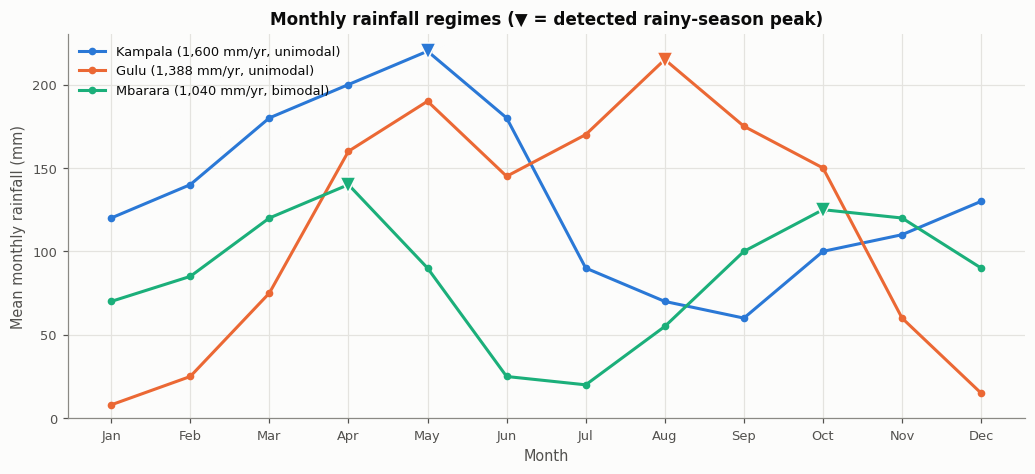

In [11]:
fig = plot_rainfall(regions, profiles)
fig.savefig(FIG_DIR / "p4_rainfall.png", bbox_inches="tight")
plt.show()

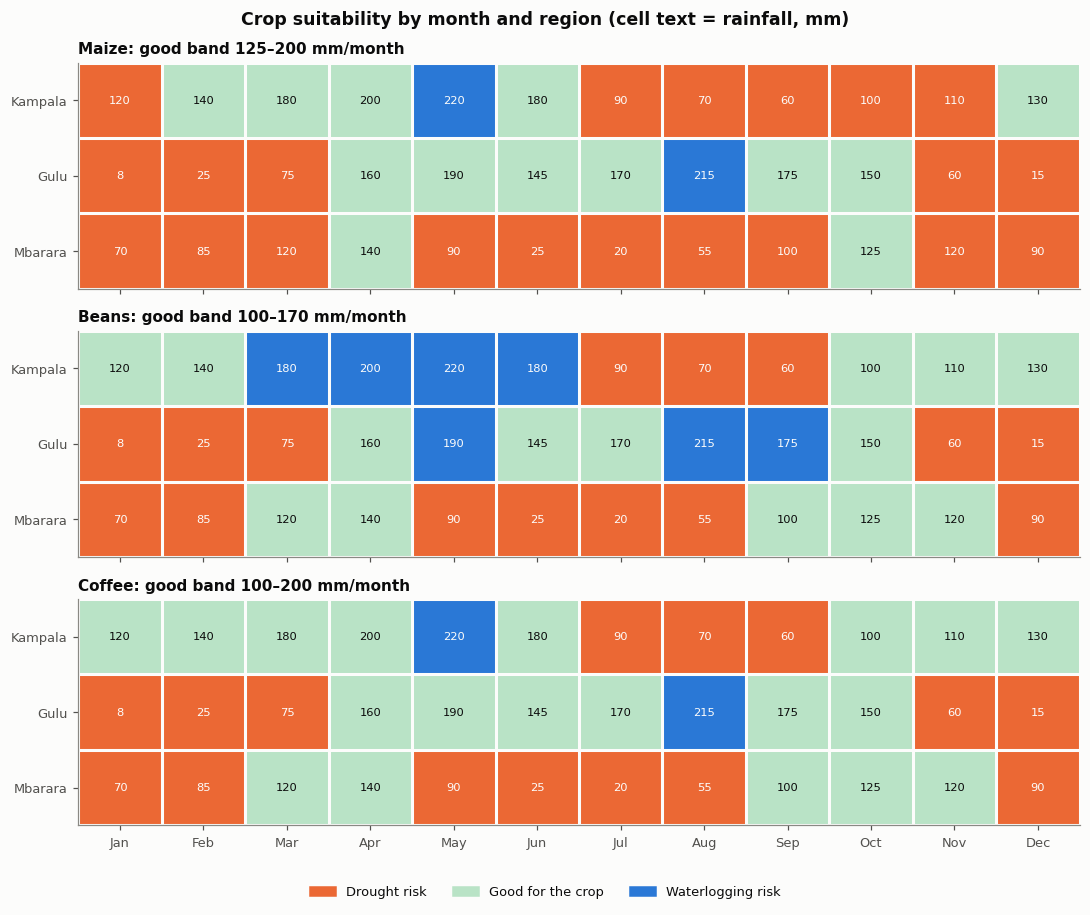

In [12]:
fig = plot_suitability_heatmap(regions, DEFAULT_CROP_RULES)
fig.savefig(FIG_DIR / "p4_suitability_heatmap.png", bbox_inches="tight")
plt.show()

In [13]:
# Longest runs of consecutive 'Good' months (wrapping over New Year) -> candidate planting windows.
pd.DataFrame({rule.crop: {r.name: "; ".join(f"{a}–{b} ({n} mo)" if a != b else f"{a} (1 mo)"
                                           for a, b, n in good_runs(rule, r)) or "none"
                          for r in regions} for rule in DEFAULT_CROP_RULES})

,Maize,Beans,Coffee
Kampala,Feb–Apr (3 mo); Jun (1 mo); Dec (1 mo),Oct–Feb (5 mo),Oct–Apr (7 mo); Jun (1 mo)
Gulu,Apr–Jul (4 mo); Sep–Oct (2 mo),Jun–Jul (2 mo); Apr (1 mo); Oct (1 mo),Apr–Jul (4 mo); Sep–Oct (2 mo)
Mbarara,Apr (1 mo); Oct (1 mo),Sep–Nov (3 mo); Mar–Apr (2 mo),Sep–Nov (3 mo); Mar–Apr (2 mo)


## 7. Advisory note for farmers in Mbarara (≤ 200 words)

> **Beans are your best crop. Plant them at the very start of each rains.**
>
> Mbarara has two short rainy seasons, with the heaviest rain in **April** and **October**. The rain suits beans in
> **March–April** and **September–November**, but it is usually too little for maize, which needs more water for
> longer.
>
> **Main season (September–November).** Plant beans as soon as the September rains are steady, usually in the first
> two weeks of September. The crop grows through three good months and ripens as the December dry weather arrives,
> which helps the grain dry without rotting.
>
> **Short season (March–April).** Plant in early March and choose an **early-maturing** bean variety. From May the rain
> drops quickly, and June–July are very dry. Late-planted beans run dry while flowering.
>
> **Do not plant in May–August** without irrigation.
>
> **Coffee** can do well if you mulch and keep shade trees to carry it through June–July. **Maize** is risky here;
> grow it only in the wettest spots, planted with the first rains.
>
> Watch UNMA seasonal forecasts: in a late or weak season, delay planting.

## References

* Basalirwa, C. P. K. (1995). Delineation of Uganda into climatological rainfall zones using the method of principal component analysis. *International Journal of Climatology*, 15(10), 1161–1177.
* Brouwer, C. & Heibloem, M. (1986). *Irrigation Water Management: Irrigation Water Needs* (Training Manual No. 3). FAO.
* DaMatta, F. M. & Ramalho, J. D. C. (2006). Impacts of drought and temperature stress on coffee physiology and production: a review. *Brazilian Journal of Plant Physiology*, 18(1), 55–81.
* Manning, C. D., Raghavan, P. & Schütze, H. (2008). *Introduction to Information Retrieval*. Cambridge University Press.
* Virtanen, P. et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272.

## Findings & Limitations

**Findings.** Rainfall timing matters more than annual totals. Kampala receives the most rain (1,600 mm) and is the
least seasonal. Gulu gets almost as much, but in one long season. Mbarara is the driest, with two short seasons and a
harsh June–July dry spell. Crop suitability follows timing. Gulu offers the longest continuous maize window
(April–July). Kampala's March–June rains are too heavy for beans but suit beans and coffee from October to February.
Mbarara is best for beans in two short windows and marginal for maize (two suitable months).

The choice of similarity measure changes the conclusion. Cosine similarity rates every pair between
0.75 and 0.89, i.e. "similar". Pearson correlation shows Gulu's regime is uncorrelated or anti-correlated with the
southern regions. An adviser relying on cosine would transfer planting calendars between regions whose seasons are
out of phase. Circular, prominence-filtered peak detection reproduces the known regimes of Gulu (unimodal, with a June
lull) and Mbarara (bimodal). Kampala's mismatch traces back to the illustrative data, not the method.

**Limitations.** Twelve monthly means hide what matters most to farmers: year-to-year variability in onset dates and
mid-season dry spells. The real-data extension (NASA POWER/UNMA) was not attempted. Monthly totals also hide intra-month
distribution (150 mm in two storms can still stress a crop). The thresholds divide a seasonal requirement evenly across
months, whereas water need peaks at flowering and depends on evapotranspiration, soil storage and altitude. The
waterlogging limit depends on soil drainage. A monthly band also ignores coffee's need for a dry spell to trigger
flowering. The citations provide seasonal ranges; the monthly conversion is our own assumption. Finally, the prominence
threshold was chosen by argument, using only three regions.